In [1]:
import sys
sys.path.append("../../../")

from utils.misc import select_cuda_device
device = select_cuda_device()

Selected device 1, which has 10820 MB available.


In [2]:
import torch

import matplotlib.pyplot as plt

import pickle

from einops import rearrange

from hydra import initialize, compose
from hydra.utils import instantiate

from smcdet.images import ImageModel, M71ImageModel

In [3]:
with initialize(config_path=".", version_base=None):
    cfg = compose(config_name="config")

In [4]:
with open('data/params.pkl', 'rb') as f:
    params = pickle.load(f)

params

{'flux_alpha': 0.21411753249015655,
 'flux_lower': 0.06291294097900389,
 'flux_upper': 1804.6791992187502,
 'flux_detection_threshold': 0.25165176391601557,
 'counts_rate': 0.030264640226960182,
 'background': 104.1486587524414,
 'adu_per_nmgy': 241.008056640625,
 'psf_params': tensor([1.1233, 2.1415, 2.5461, 5.3279, 0.6738, 0.4064]),
 'psf_radius': 8,
 'noise_additive': 1.0000007072408224e-10,
 'noise_multiplicative': 1.9366955757141113}

---

**Gaussian PSF (default in `ImageModel`):**

In [5]:
image_model = ImageModel(
    h_lower=0, h_upper=25,
    w_lower=0, w_upper=25,
    background=params["background"],
    psf_radius=8,
    psf_stdev=1.9273269405185427,
)

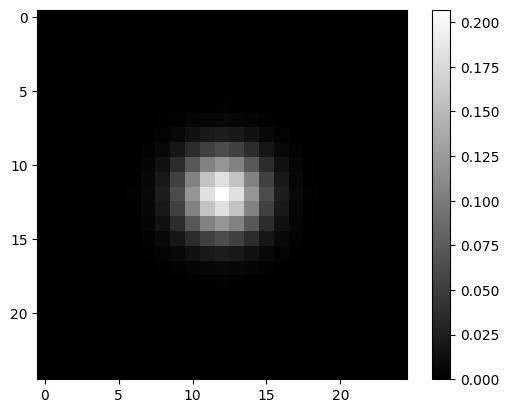

In [6]:
locs = torch.zeros([1,1,1,1,2])
locs[...,0,:] = torch.tensor([12.5, 12.5])

gaussian_psf = image_model.psf(locs).squeeze()

_ = plt.imshow(gaussian_psf, cmap = 'gray')
_ = plt.colorbar()

**SDSS PSF (rasterized):**

In [7]:
sdss = instantiate(cfg.surveys.sdss)
sdss.prepare_data()

In [8]:
sdss_psf = sdss.psf.psf_galsim[sdss.image_id(0)][2].original.image.array

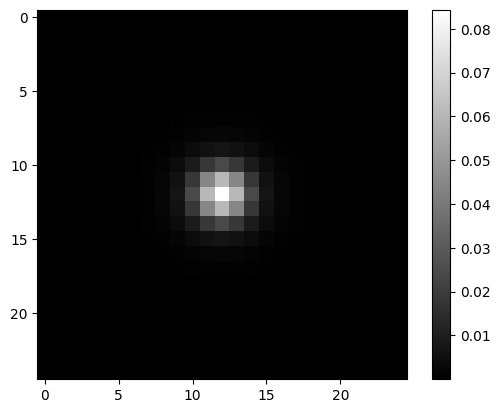

In [9]:
_ = plt.imshow(sdss_psf, cmap = 'gray')
_ = plt.colorbar()

**SDSS PSF (model-based, with a Gaussian core and a power-law wing):**

In [10]:
m71_image_model = M71ImageModel(
    h_lower=0, h_upper=sdss_psf.shape[0],
    w_lower=0, w_upper=sdss_psf.shape[1],
    background=params["background"],
    adu_per_nmgy=params["adu_per_nmgy"],
    psf_params=params["psf_params"],
    psf_radius=params["psf_radius"],
    noise_additive=params["noise_additive"],
    noise_multiplicative=params["noise_multiplicative"],
)

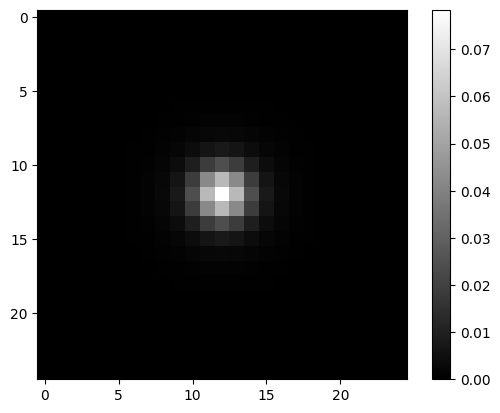

In [11]:
sdss_psf2 = m71_image_model.psf(locs).squeeze()
_ = plt.imshow(sdss_psf2, cmap = 'gray')
_ = plt.colorbar()

**Compare the two SDSS PSFs:**

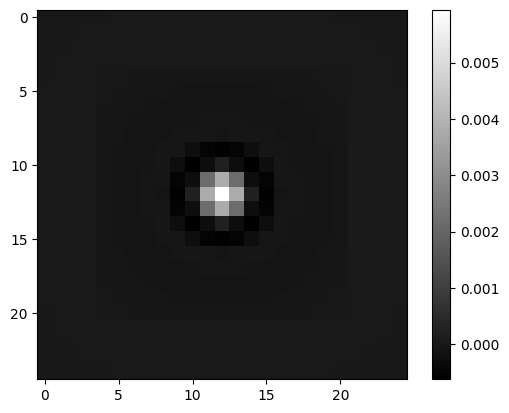

In [12]:
_ = plt.imshow(sdss_psf - sdss_psf2.numpy(), cmap = 'gray')
_ = plt.colorbar()

---

**Compare to empirical PSF from an M71 tile with one isolated source**

In [13]:
tiles = torch.load("data/tiles.pt")
counts = torch.load("data/pruned_counts_magcut.pt")
locs = torch.load("data/pruned_locs_magcut.pt")
fluxes = torch.load("data/pruned_fluxes_magcut.pt")

In [14]:
m71_image_model = M71ImageModel(
    h_lower=0, h_upper=tiles.shape[1],
    w_lower=0, w_upper=tiles.shape[2],
    background=params["background"],
    adu_per_nmgy=params["adu_per_nmgy"],
    psf_params=params["psf_params"],
    psf_radius=params["psf_radius"],
    noise_additive=params["noise_additive"],
    noise_multiplicative=params["noise_multiplicative"],
)

Here's an actual tile:

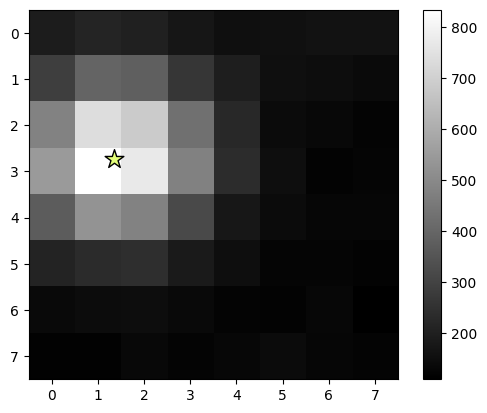

In [15]:
idx = torch.where((counts == 1) * ((locs[...,0,0] - 4).abs() < 2) * ((locs[...,0,1] - 2).abs() < 1))[0][1].item()
_ = plt.imshow(tiles[idx], cmap = 'gray')
_ = plt.colorbar()
_ = plt.scatter(locs[idx][...,:1,1] - 0.5,
                locs[idx][...,:1,0] - 0.5,
                c = fluxes[idx][...,0], marker = '*', cmap = 'Wistia', s = 200, edgecolors = 'black')

Here's a noiseless reconstruction based on our PSF model:

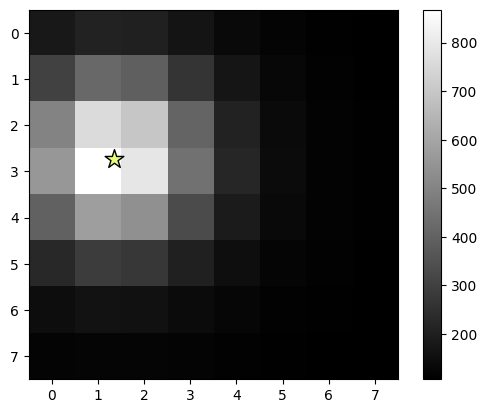

In [16]:
psf = m71_image_model.psf(rearrange(locs[idx], "d t -> 1 1 1 d t"))
rate = (
    psf
    * rearrange(
        m71_image_model.adu_per_nmgy * rearrange(fluxes[idx], "d -> 1 1 1 d"), "numH numW n d -> numH numW 1 1 n d"
    )
).sum(-1) + m71_image_model.background
rate = rate.squeeze()

_ = plt.imshow(rate, cmap = 'gray')
_ = plt.colorbar()
_ = plt.scatter(locs[idx][...,:1,1] - 0.5,
                locs[idx][...,:1,0] - 0.5,
                c = fluxes[idx][...,0], marker = '*', cmap = 'Wistia', s = 200, edgecolors = 'black')

And here's the difference between the actual tile and our noiseless reconstruction:

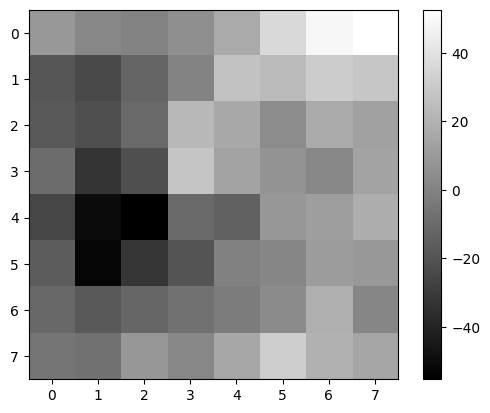

In [17]:
_ = plt.imshow(tiles[idx] - rate, cmap = 'gray')
_ = plt.colorbar()